# 02 - Analise Exploratoria Inicial

Objetivo deste notebook: comecar a responder perguntas de negocio usando as tabelas da Olist.

Nesta etapa vamos analisar:

- status dos pedidos;
- periodo coberto pelos dados;
- evolucao mensal de pedidos;
- receita estimada;
- categorias com maior faturamento;
- relacao inicial entre atraso de entrega e avaliacao do cliente.

## 1. Importar bibliotecas

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", palette="deep")

## 2. Definir caminhos e carregar dados

In [2]:
PROJECT_ROOT = Path("..").resolve()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

orders = pd.read_csv(RAW_DATA_DIR / "olist_orders_dataset.csv")
items = pd.read_csv(RAW_DATA_DIR / "olist_order_items_dataset.csv")
payments = pd.read_csv(RAW_DATA_DIR / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(RAW_DATA_DIR / "olist_order_reviews_dataset.csv")
products = pd.read_csv(RAW_DATA_DIR / "olist_products_dataset.csv")
customers = pd.read_csv(RAW_DATA_DIR / "olist_customers_dataset.csv")
category_translation = pd.read_csv(RAW_DATA_DIR / "product_category_name_translation.csv")

orders.shape, items.shape, payments.shape, reviews.shape, products.shape

((99441, 8), (112650, 7), (103886, 5), (99224, 7), (32951, 9))

## 3. Converter colunas de data

As datas vieram como texto. Para analisar tempo, precisamos converter essas colunas para o tipo `datetime`.

In [3]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

orders[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

## 4. Quantos pedidos existem por status?

Esta pergunta mostra a situacao operacional dos pedidos: entregues, enviados, cancelados, indisponiveis etc.

In [4]:
order_status = (
    orders["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="orders")
)

order_status

,order_status,orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


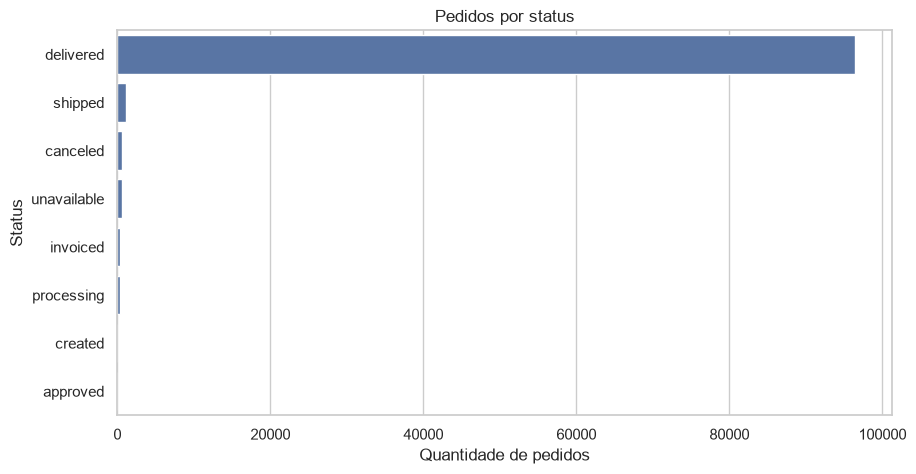

In [5]:
plt.figure(figsize=(10, 5))
sns.barplot(data=order_status, x="orders", y="order_status")
plt.title("Pedidos por status")
plt.xlabel("Quantidade de pedidos")
plt.ylabel("Status")
plt.show()

## 5. Qual periodo o dataset cobre?

In [6]:
period = pd.DataFrame({
    "first_purchase": [orders["order_purchase_timestamp"].min()],
    "last_purchase": [orders["order_purchase_timestamp"].max()],
})

period

,first_purchase,last_purchase
0,2016-09-04 21:15:19,2018-10-17 17:30:18


## 6. Evolucao mensal de pedidos

Aqui contamos os pedidos por mes de compra. Para evitar distorcoes, vamos focar nos pedidos com status `delivered`.

In [7]:
delivered_orders = orders[orders["order_status"] == "delivered"].copy()
delivered_orders["purchase_month"] = delivered_orders["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

monthly_orders = (
    delivered_orders
    .groupby("purchase_month")
    .agg(orders=("order_id", "nunique"))
    .reset_index()
)

monthly_orders.head()

,purchase_month,orders
0,2016-09-01,1
1,2016-10-01,265
2,2016-12-01,1
3,2017-01-01,750
4,2017-02-01,1653


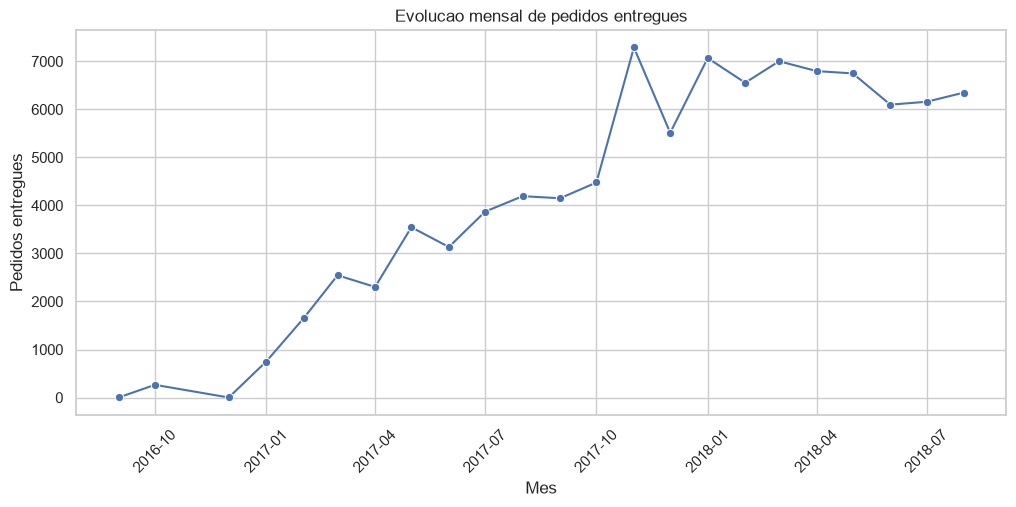

In [8]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_orders, x="purchase_month", y="orders", marker="o")
plt.title("Evolucao mensal de pedidos entregues")
plt.xlabel("Mes")
plt.ylabel("Pedidos entregues")
plt.xticks(rotation=45)
plt.show()

## 7. Receita estimada

Neste dataset, a receita de produtos pode ser estimada pela soma de `price` na tabela de itens. O frete fica separado em `freight_value`.

In [9]:
revenue_kpis = pd.DataFrame({
    "total_product_revenue": [items["price"].sum()],
    "total_freight_value": [items["freight_value"].sum()],
    "total_orders_with_items": [items["order_id"].nunique()],
    "average_ticket_products": [items.groupby("order_id")["price"].sum().mean()],
})

revenue_kpis

,total_product_revenue,total_freight_value,total_orders_with_items,average_ticket_products
0,13591643.7,2251909.54,98666,137.754076


## 8. Categorias com maior faturamento

Para analisar categorias, precisamos juntar itens com produtos e traducao de categorias.

In [10]:
items_products = (
    items
    .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(category_translation, on="product_category_name", how="left")
)

items_products["category"] = items_products["product_category_name_english"].fillna("unknown")

category_revenue = (
    items_products
    .groupby("category")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        items=("order_item_id", "count"),
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

category_revenue.head(10)

,category,revenue,orders,items
43,health_beauty,1258681.34,8836,9670
71,watches_gifts,1205005.68,5624,5991
7,bed_bath_table,1036988.68,9417,11115
65,sports_leisure,988048.97,7720,8641
15,computers_accessories,911954.32,6689,7827
39,furniture_decor,729762.49,6449,8334
20,cool_stuff,635290.85,3632,3796
49,housewares,632248.66,5884,6964
5,auto,592720.11,3897,4235
42,garden_tools,485256.46,3518,4347


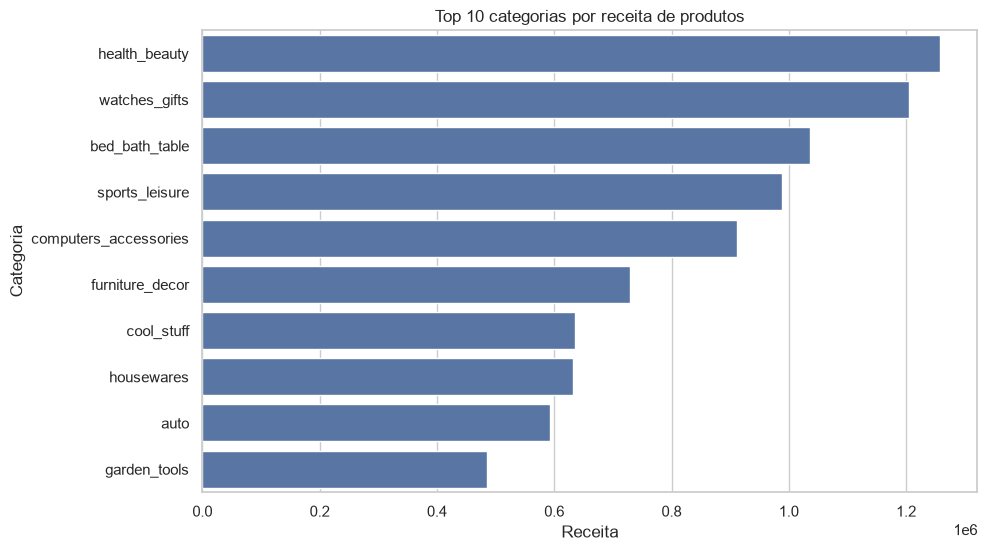

In [11]:
top_categories = category_revenue.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_categories, x="revenue", y="category")
plt.title("Top 10 categorias por receita de produtos")
plt.xlabel("Receita")
plt.ylabel("Categoria")
plt.show()

## 9. Entrega atrasada e avaliacao

Agora criamos uma variavel simples: se a entrega ao cliente aconteceu depois da data estimada.

In [12]:
delivery_reviews = (
    delivered_orders[[
        "order_id",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]]
    .merge(reviews[["order_id", "review_score"]], on="order_id", how="left")
)

delivery_reviews["delivery_delay_days"] = (
    delivery_reviews["order_delivered_customer_date"]
    - delivery_reviews["order_estimated_delivery_date"]
).dt.days

delivery_reviews["is_late"] = delivery_reviews["delivery_delay_days"] > 0

delivery_reviews.head()

,order_id,order_delivered_customer_date,order_estimated_delivery_date,review_score,delivery_delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,4.0,-8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,4.0,-6.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,5.0,-18.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,5.0,-13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,5.0,-10.0,False


In [13]:
late_review_summary = (
    delivery_reviews
    .groupby("is_late")
    .agg(
        orders=("order_id", "nunique"),
        average_review_score=("review_score", "mean"),
        average_delay_days=("delivery_delay_days", "mean"),
    )
    .reset_index()
)

late_review_summary

,is_late,orders,average_review_score,average_delay_days
0,False,89944,4.289999,-13.512921
1,True,6534,2.271025,10.627705


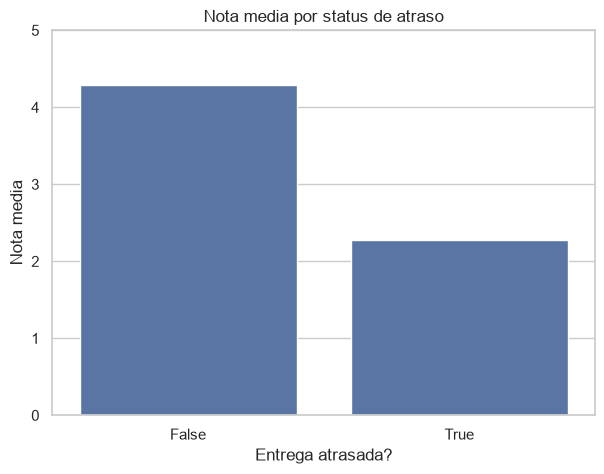

In [14]:
plt.figure(figsize=(7, 5))
sns.barplot(data=late_review_summary, x="is_late", y="average_review_score")
plt.title("Nota media por status de atraso")
plt.xlabel("Entrega atrasada?")
plt.ylabel("Nota media")
plt.ylim(0, 5)
plt.show()

## 10. Primeiras conclusoes

Preencha esta secao depois de executar as celulas:

1. A maior parte dos pedidos esta em qual status?
2. Qual periodo o dataset cobre?
3. A curva mensal mostra crescimento, queda ou sazonalidade?
4. Quais categorias lideram em receita?
5. Pedidos atrasados parecem ter nota media menor?

Estas respostas serao usadas depois no README e no post do LinkedIn.